# Ejercicio de clustering

 El objetivo es tratar de identificar grupos de pasajeros que tengan características similares con el fin de dirigirse a diferentes segmentos para distintos tipos de ofertas de millas.

---


## Descripción de los datos

El archivo EastWestAirlines contiene la información del programa de viajero frecuente de los pasajeros de una aerolínea. Para cada pasajero los datos incluyen información del historial de millas

Para cada pasajero, los datos incluyen información sobre su historial de millas y sobre las diferentes formas en que acumularon o gastaron millas en el último año. El objetivo es tratar de identificar grupos de pasajeros que tengan características similares con el fin de dirigirse a diferentes segmentos para distintos tipos de ofertas de millas.

ID# --Unique ID

Balance--Number of miles eligible for award travel

Qual_mile--Number of miles counted as qualifying for Topflight status

cc1_miles -- Number of miles earned with freq. flyer credit card in the past 12 months:

cc2_miles -- Number of miles earned with Rewards credit card in the past 12 months:

cc3_miles -- Number of miles earned with Small Business credit card in the past 12 months:

1 = under 5,000

2 = 5,000 - 10,000

3 = 10,001 - 25,000

4 = 25,001 - 50,000

5 = over 50,000

Bonus_miles--Number of miles earned from non-flight bonus transactions in the past 12 months

Bonus_trans--Number of non-flight bonus transactions in the past 12 months

Flight_miles_12mo--Number of flight miles in the past 12 months

Flight_trans_12--Number of flight transactions in the past 12 months

Days_since_enrolled--Number of days since enrolled in flier program

Award?--whether that person had award flight (free flight) or not


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

from scipy.cluster.hierarchy import dendrogram, linkage

Mounted at /content/drive


In [ ]:
datos =pd.read_csv("/content/drive/MyDrive/Colab aprendizaje no supervisado/Taller/EastWestAirlines.csv")
datos.head()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
datos.isna().sum()

,0
ID,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [ ]:
datos =datos.dropna()

In [ ]:
datos.shape

(3999, 12)

In [ ]:
datos.columns

Index(['ID', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award'],
      dtype='object')

In [ ]:
datos_cat = datos[['Balance','Qual_miles','cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles','Bonus_trans', 'Flight_miles_12mo', 'Days_since_enroll','Award']]
datos_cat.head()
#

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,7000,0
1,19244,0,1,1,1,215,2,0,6968,0
2,41354,0,1,1,1,4123,4,0,7034,0
3,14776,0,1,1,1,500,1,0,6952,0
4,97752,0,4,1,1,43300,26,2077,6935,1


In [ ]:
corr_matrix = datos_cat.corr()
corr_matrix

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
Balance,1.000000,0.108722,0.338344,-0.008804,0.035243,0.403487,0.324935,0.217551,0.263129,0.178494
Qual_miles,0.108722,1.000000,0.007931,-0.013923,-0.007779,0.031021,0.050725,0.126774,0.017312,0.095256
cc1_miles,0.338344,0.007931,1.000000,-0.068223,0.060555,0.825200,0.608943,0.037370,0.230849,0.335457
cc2_miles,-0.008804,-0.013923,-0.068223,1.000000,-0.006166,-0.003969,0.064399,0.010598,-0.005807,0.005332
cc3_miles,0.035243,-0.007779,0.060555,-0.006166,1.000000,0.204134,0.097313,-0.001777,0.010832,0.023484
Bonus_miles,0.403487,0.031021,0.825200,-0.003969,0.204134,1.000000,0.603180,0.183536,0.210397,0.373506
Bonus_trans,0.324935,0.050725,0.608943,0.064399,0.097313,0.603180,1.000000,0.377216,0.161262,0.333893
Flight_miles_12mo,0.217551,0.126774,0.037370,0.010598,-0.001777,0.183536,0.377216,1.000000,0.037271,0.217715
Days_since_enroll,0.263129,0.017312,0.230849,-0.005807,0.010832,0.210397,0.161262,0.037271,1.000000,0.188121
Award,0.178494,0.095256,0.335457,0.005332,0.023484,0.373506,0.333893,0.217715,0.188121,1.000000


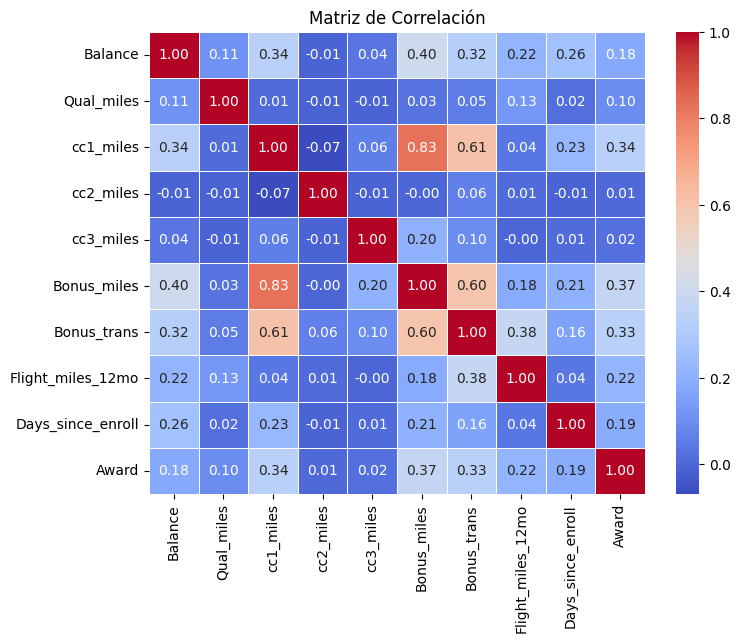

In [ ]:
plt.figure(figsize=(8,6))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

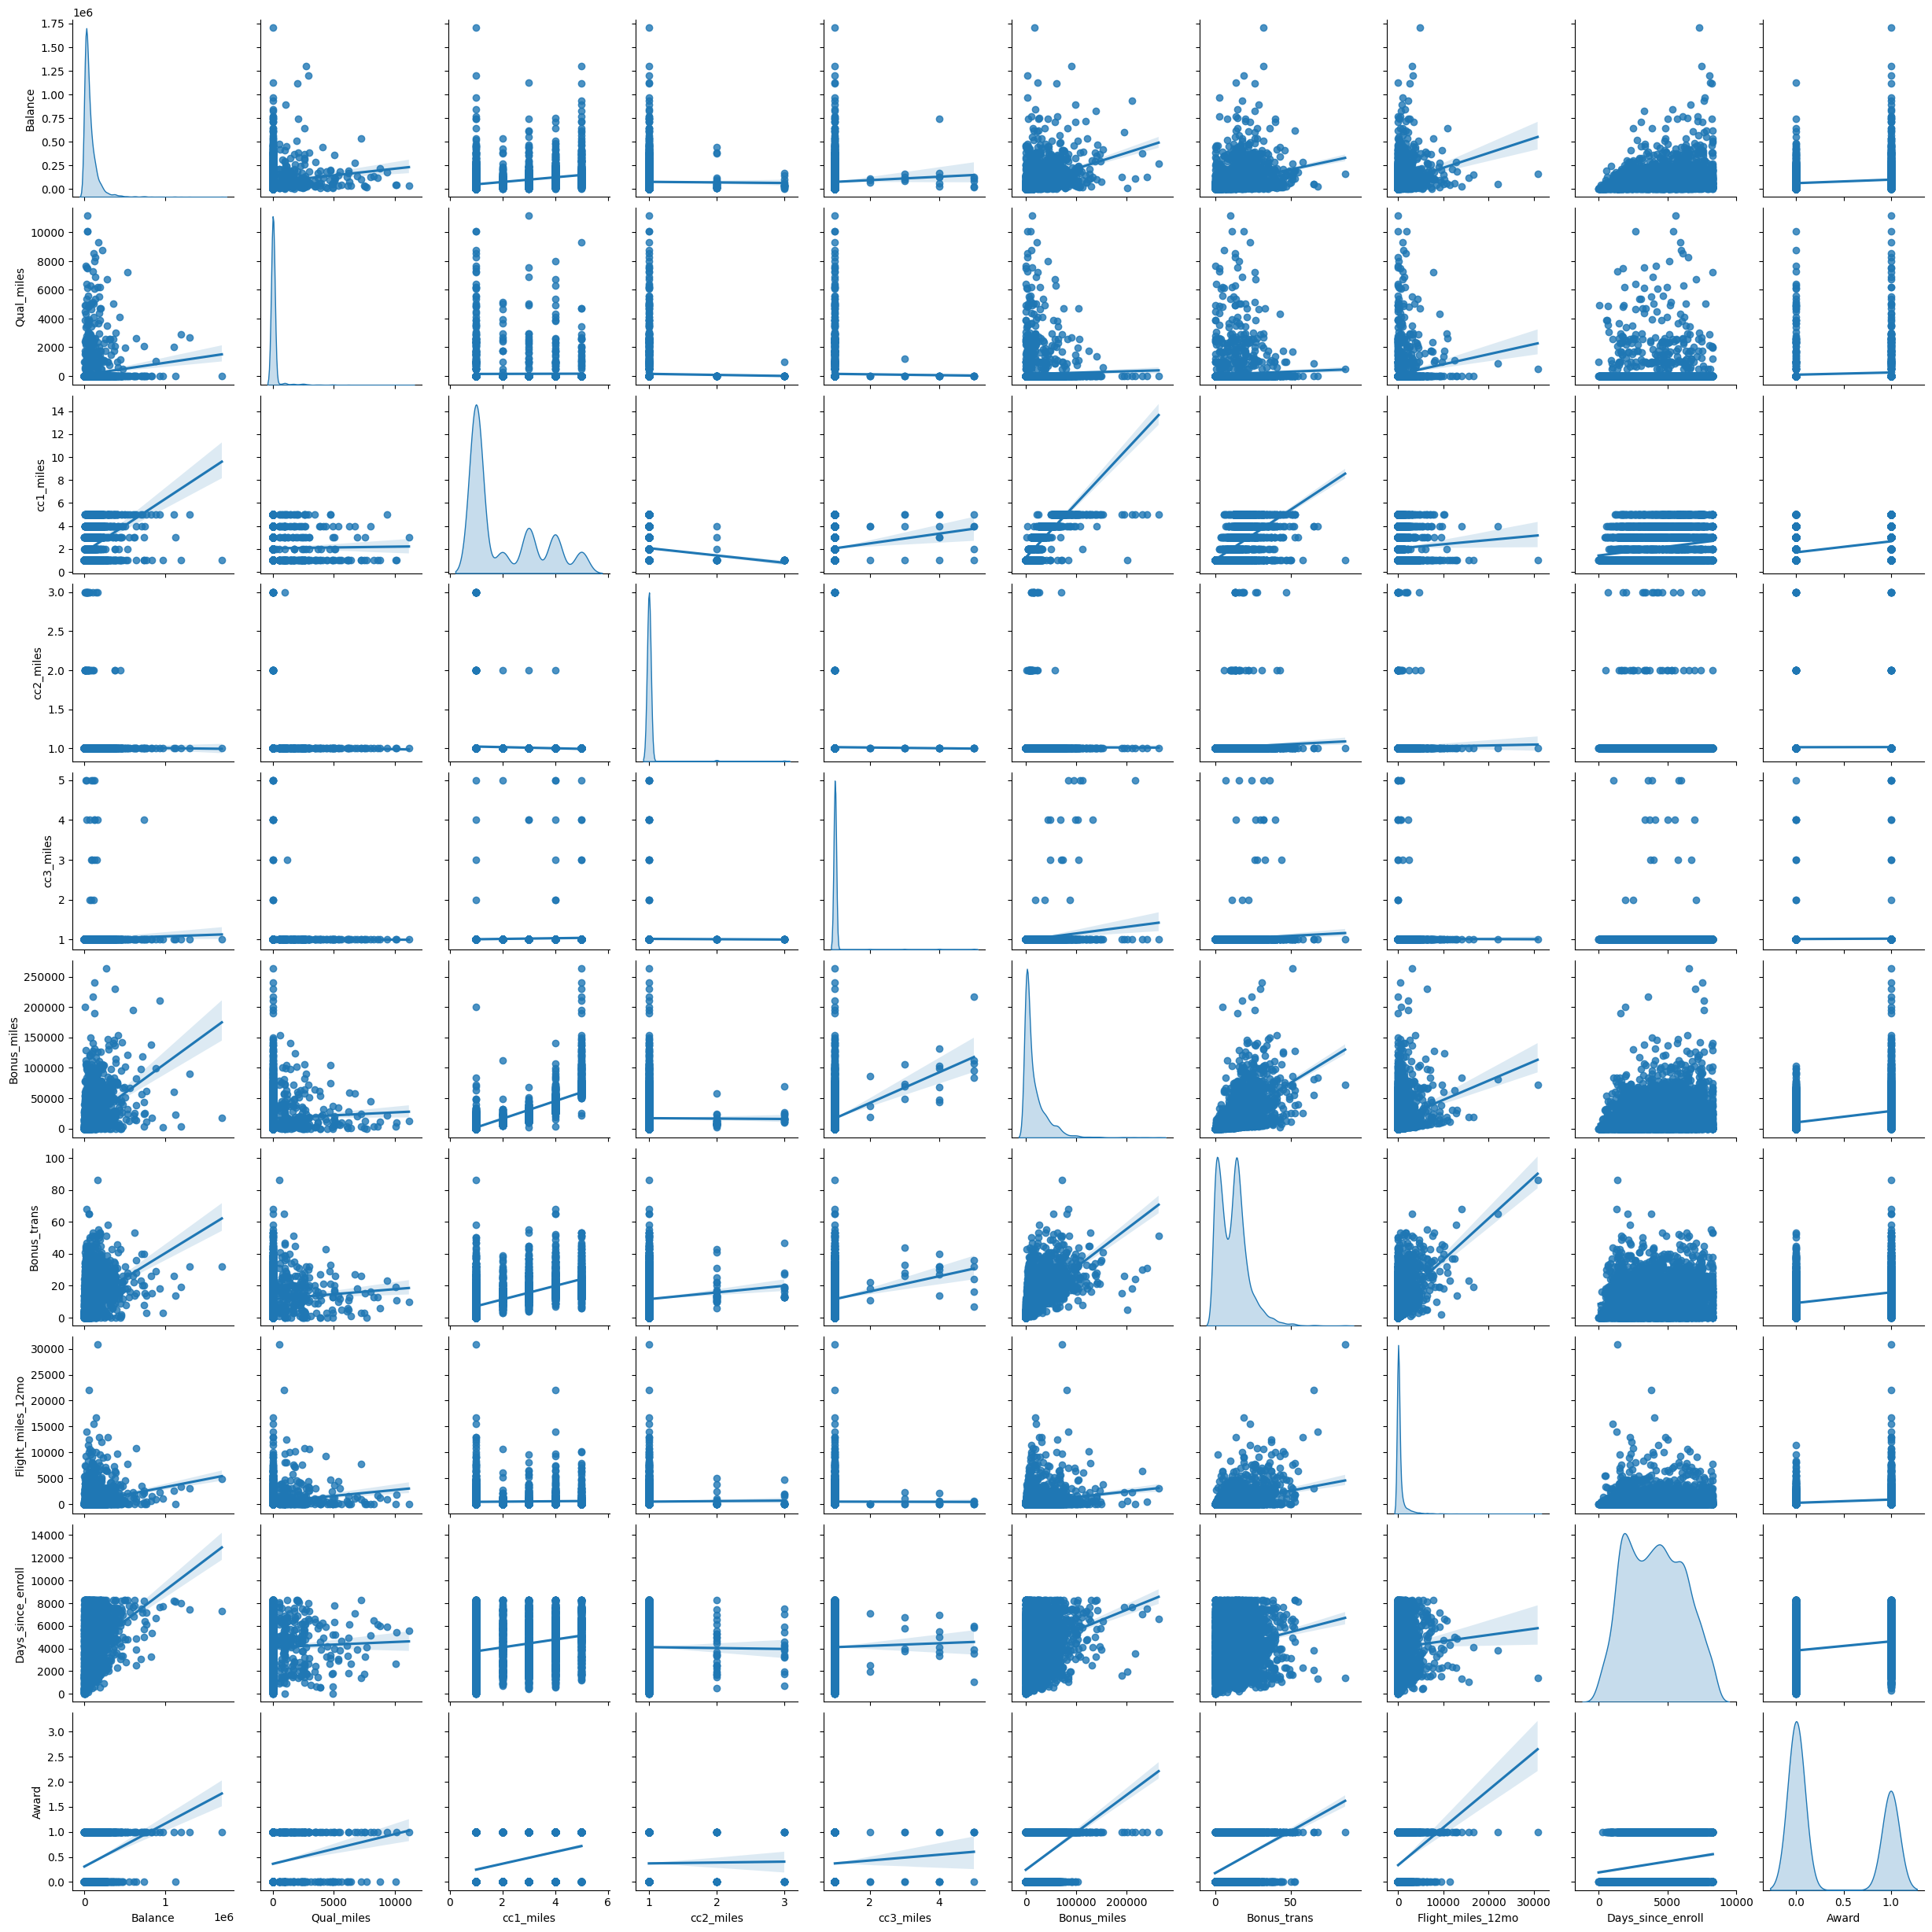

In [ ]:
sns.pairplot(datos_cat, kind="reg", diag_kind="kde")
plt.show()


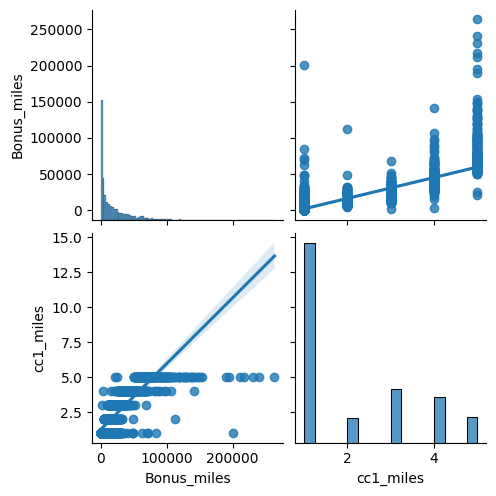

In [ ]:
sns.pairplot(datos_cat[['Bonus_miles','cc1_miles']], kind="reg")
plt.show()

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(datos_cat)
scaled_features

array([[-4.51140783e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01,  1.39545434e+00, -7.66919299e-01],
       [-5.39456874e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01,  1.37995704e+00, -7.66919299e-01],
       [-3.20031232e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01,  1.41192021e+00, -7.66919299e-01],
       ...,
       [-4.29480975e-05, -1.86298687e-01,  6.83121167e-01, ...,
        -3.28603258e-01, -1.31560393e+00,  1.30391816e+00],
       [-1.85606976e-01, -1.86298687e-01, -7.69578406e-01, ...,
         2.85309024e-02, -1.31608822e+00, -7.66919299e-01],
       [-7.00507951e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01, -1.31754109e+00, -7.66919299e-01]])

In [ ]:
est=pd.DataFrame(scaled_features, columns=datos_cat.columns)
est

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...
3994,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-1.315120,1.303918
3995,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-1.318994,1.303918
3996,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-1.315604,1.303918
3997,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-1.316088,-0.766919


In [ ]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=2, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [ ]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=2, n_init=10, random_state=42)

In [ ]:
kmeans.inertia_

31668.286112792237

In [ ]:
kmeans.cluster_centers_

array([[-0.28637239, -0.06530261, -0.56572399,  0.02546547, -0.06085733,
        -0.49369411, -0.44348654, -0.1508194 , -0.19474703, -0.33005981],
       [ 0.5838428 ,  0.13313594,  1.15337194, -0.05191782,  0.12407311,
         1.00652075,  0.90415986,  0.30748362,  0.39704125,  0.6729107 ]])

In [ ]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[4.47455680e+04, 9.35985837e+01, 1.28065598e+00, 1.01826314e+00,
        1.00037272e+00, 5.22314648e+03, 7.34327246e+00, 2.48903466e+02,
        3.71643086e+03, 2.10957883e-01],
       [1.32431117e+05, 2.47104103e+02, 3.64741641e+00, 1.00683891e+00,
        1.03647416e+00, 4.14502568e+04, 2.02841945e+01, 8.90543313e+02,
        4.93840046e+03, 6.95288754e-01]])

In [ ]:
labels = kmeans.predict(scaled_features)
datos['cluster'] = labels
datos

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,0


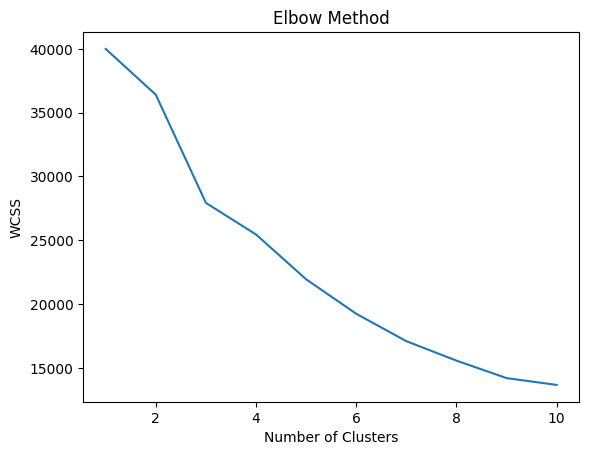

In [ ]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

En base al gráfico del codo se decide trabajar con dos clusters.

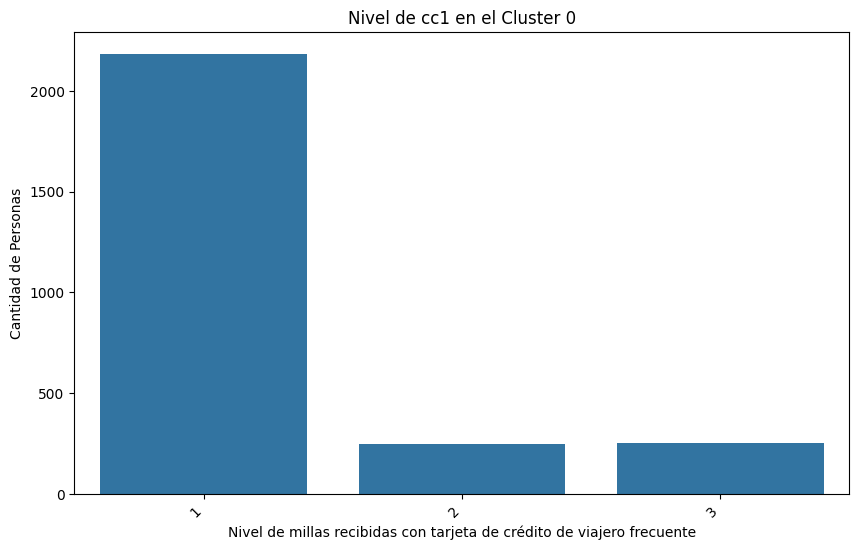

In [ ]:
# Filtrar los datos del cluster 0
cluster_0 = datos[datos['cluster'] == 0]

cc1_counts = cluster_0['cc1_miles'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=cc1_counts.index, y=cc1_counts.values)
plt.title('Nivel de cc1 en el Cluster 0')
plt.xlabel('Nivel de millas recibidas con tarjeta de crédito de viajero frecuente')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()


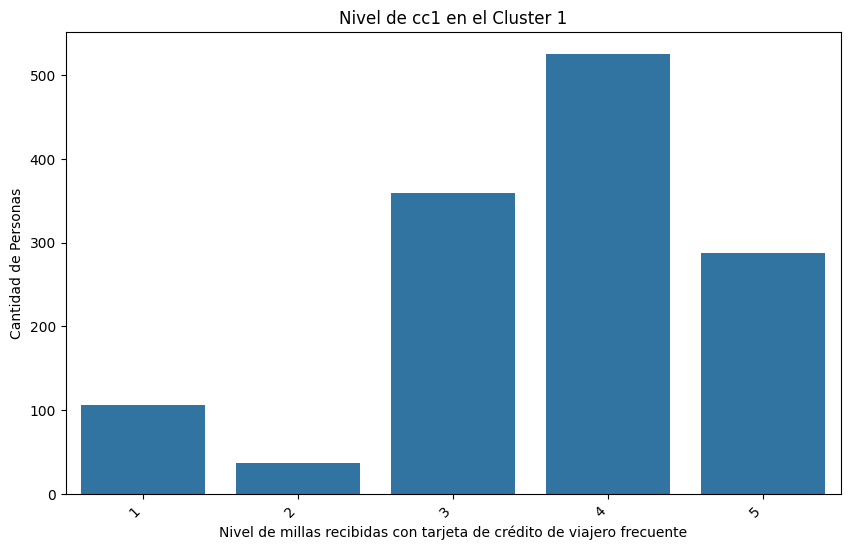

In [ ]:
# Filtrar los datos del cluster 1
cluster_1 = datos[datos['cluster'] == 1]

cc1_counts = cluster_1['cc1_miles'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=cc1_counts.index, y=cc1_counts.values)
plt.title('Nivel de cc1 en el Cluster 1')
plt.xlabel('Nivel de millas recibidas con tarjeta de crédito de viajero frecuente')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()


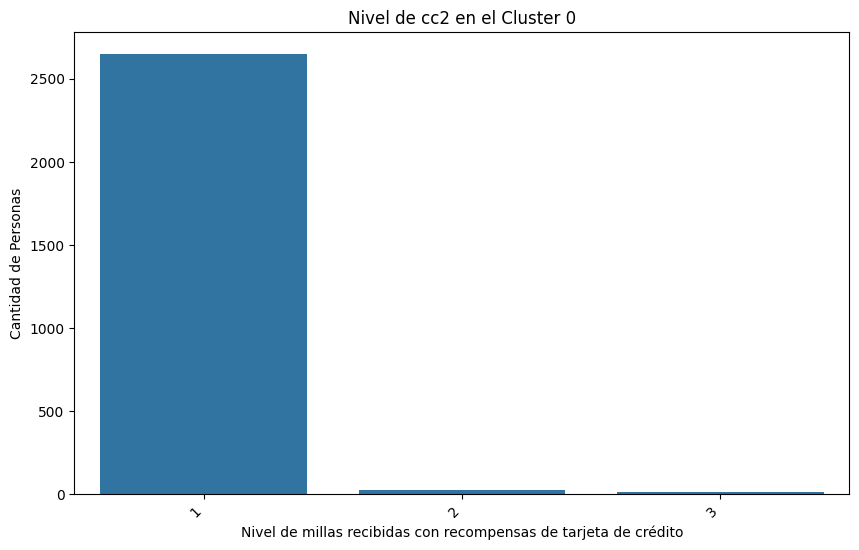

In [ ]:
# Filtrar los datos del cluster 0
cluster_0 = datos[datos['cluster'] == 0]

cc2_counts = cluster_0['cc2_miles'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=cc2_counts.index, y=cc2_counts.values)
plt.title('Nivel de cc2 en el Cluster 0')
plt.xlabel('Nivel de millas recibidas con recompensas de tarjeta de crédito')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()

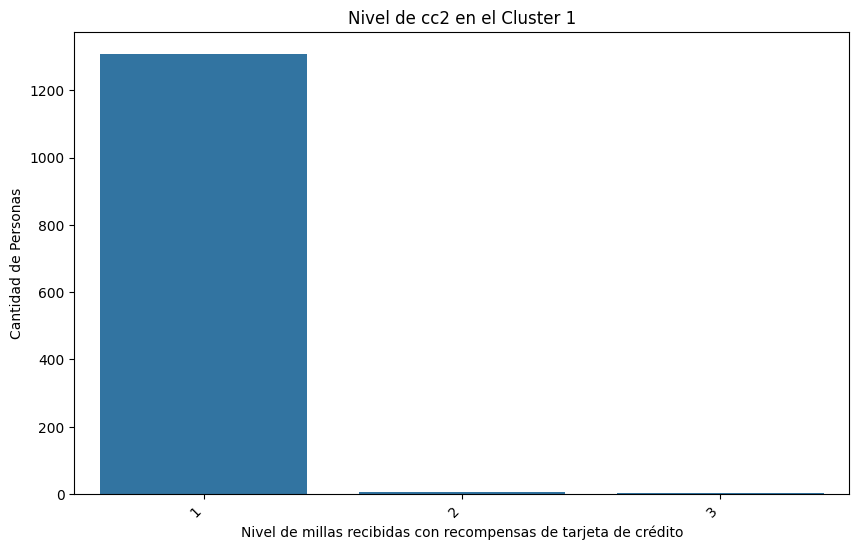

In [ ]:
# Filtrar los datos del cluster 1
cluster_1 = datos[datos['cluster'] == 1]

cc2_counts = cluster_1['cc2_miles'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=cc2_counts.index, y=cc2_counts.values)
plt.title('Nivel de cc2 en el Cluster 1')
plt.xlabel('Nivel de millas recibidas con recompensas de tarjeta de crédito')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()

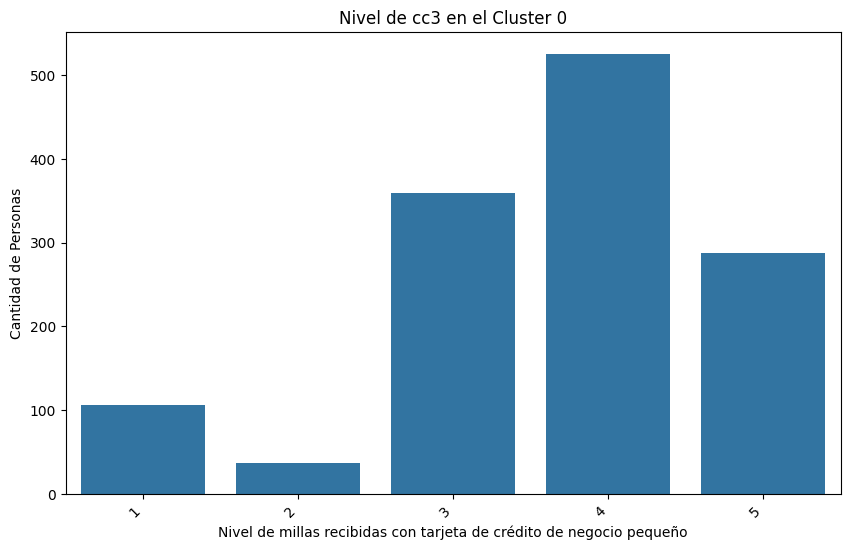

In [ ]:
# Filtrar los datos del cluster 0
cluster_0 = datos[datos['cluster'] == 0]

cc3_counts = cluster_0['cc3_miles'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=cc1_counts.index, y=cc1_counts.values)
plt.title('Nivel de cc3 en el Cluster 0')
plt.xlabel('Nivel de millas recibidas con tarjeta de crédito de negocio pequeño')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()

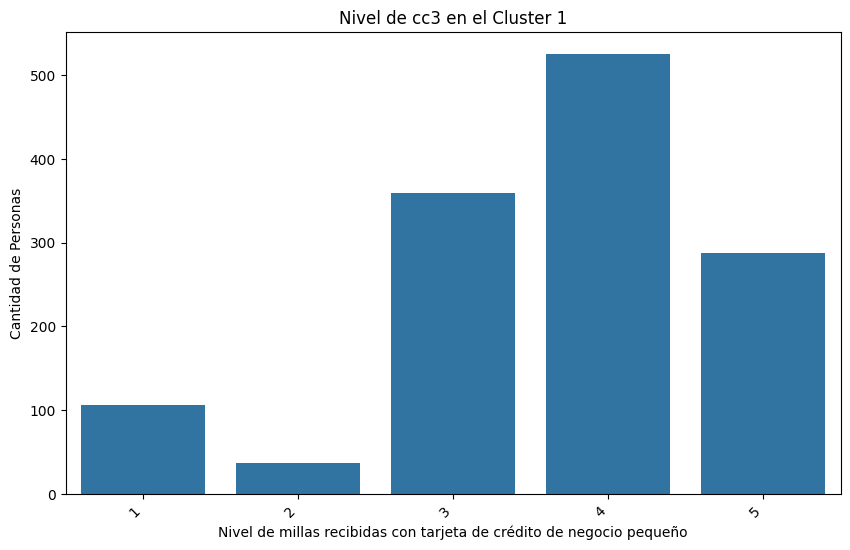

In [ ]:
# Filtrar los datos del cluster 1
cluster_1 = datos[datos['cluster'] == 1]

cc3_counts = cluster_1['cc3_miles'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=cc1_counts.index, y=cc1_counts.values)
plt.title('Nivel de cc3 en el Cluster 1')
plt.xlabel('Nivel de millas recibidas con tarjeta de crédito de negocio pequeño')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()

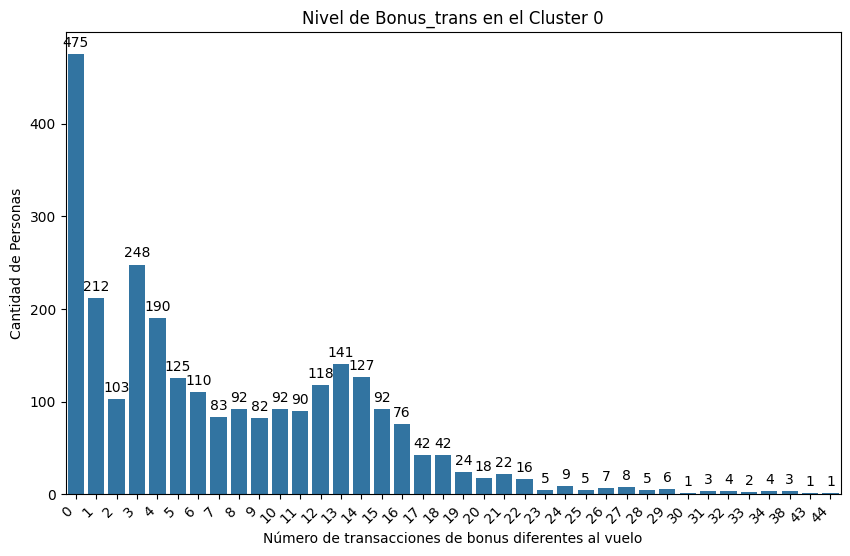

In [ ]:
# Filtrar los datos del cluster 0
cluster_0 = datos[datos['cluster'] == 0]

Bonus_trans_counts = cluster_0['Bonus_trans'].value_counts().sort_index()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=Bonus_trans_counts.index, y=Bonus_trans_counts.values)
plt.title('Nivel de Bonus_trans en el Cluster 0')
plt.xlabel('Número de transacciones de bonus diferentes al vuelo')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad

# Mostrar los valores encima de cada barra
for bar in bars.patches:
    bars.annotate(format(bar.get_height(), '.0f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=10, xytext=(0, 8),
                   textcoords='offset points')

plt.show()


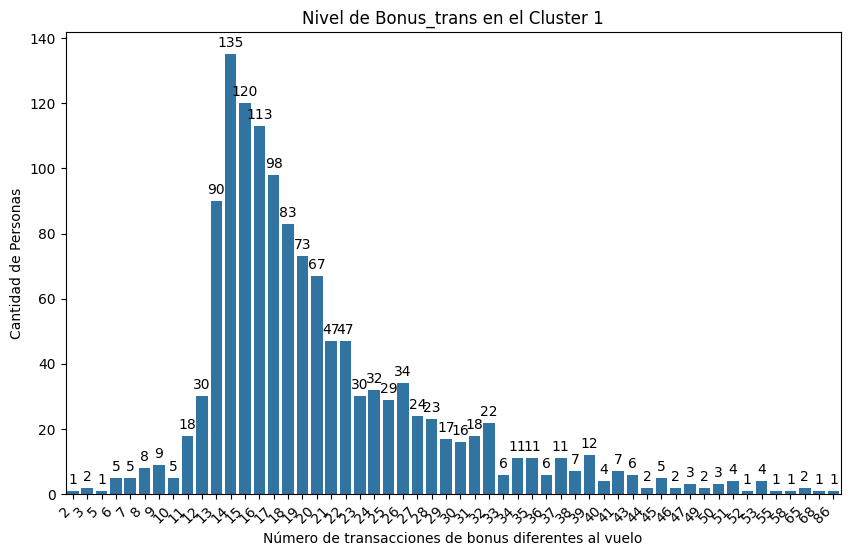

In [ ]:
# Filtrar los datos del cluster 1
cluster_1 = datos[datos['cluster'] == 1]

Bonus_trans_counts = cluster_1['Bonus_trans'].value_counts().sort_index()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=Bonus_trans_counts.index, y=Bonus_trans_counts.values)
plt.title('Nivel de Bonus_trans en el Cluster 1')
plt.xlabel('Número de transacciones de bonus diferentes al vuelo')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad

# Mostrar los valores encima de cada barra
for bar in bars.patches:
    bars.annotate(format(bar.get_height(), '.0f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=10, xytext=(0, 8),
                   textcoords='offset points')

plt.show()


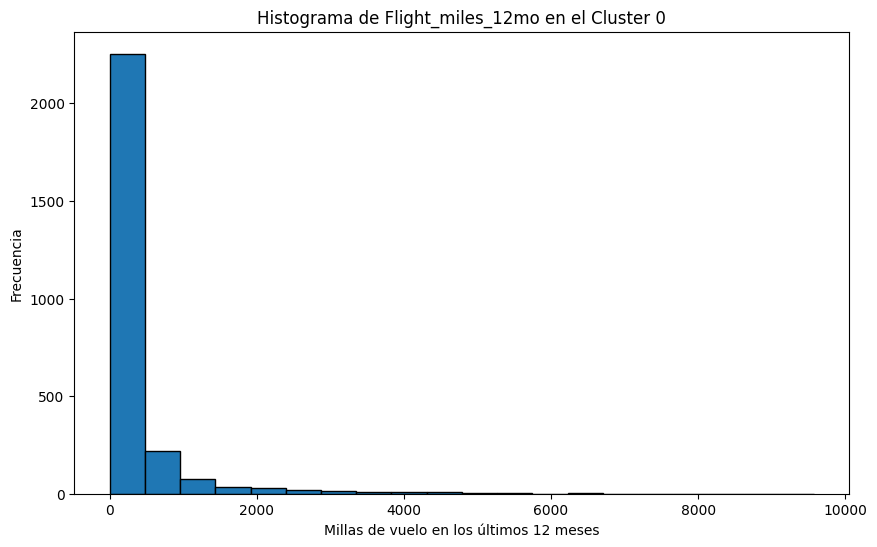

In [ ]:
import matplotlib.pyplot as plt

# Filtrar los datos del cluster 0
cluster_0 = datos[datos['cluster'] == 0]

# Crear el histograma para 'Flight_miles_12mo' en el cluster 0
plt.figure(figsize=(10, 6))
plt.hist(cluster_0['Flight_miles_12mo'], bins=20, edgecolor='black')  # Ajusta el número de bins según sea necesario
plt.title('Histograma de Flight_miles_12mo en el Cluster 0')
plt.xlabel('Millas de vuelo en los últimos 12 meses')
plt.ylabel('Frecuencia')
plt.show()


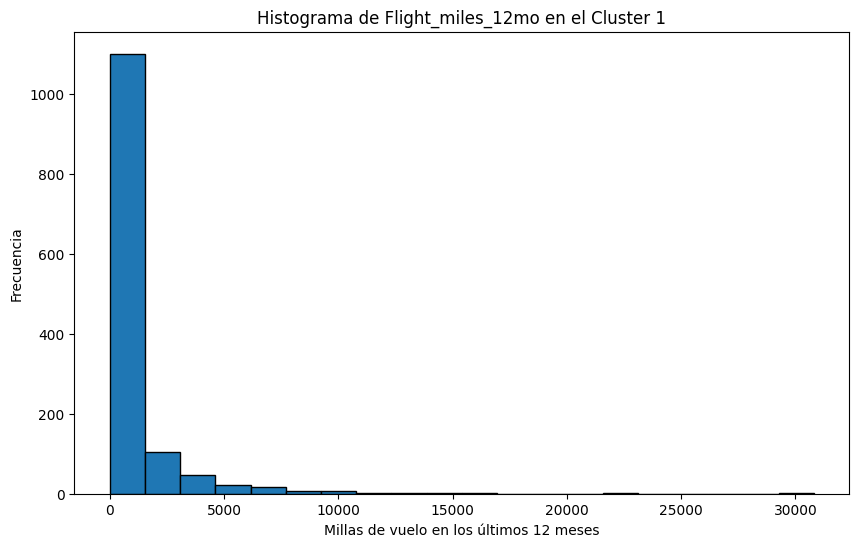

In [ ]:
# Filtrar los datos del cluster 1
cluster_1 = datos[datos['cluster'] == 1]

# Crear el histograma para 'Flight_miles_12mo' en el cluster 1
plt.figure(figsize=(10, 6))
plt.hist(cluster_1['Flight_miles_12mo'], bins=20, edgecolor='black')  # Ajusta el número de bins según sea necesario
plt.title('Histograma de Flight_miles_12mo en el Cluster 1')
plt.xlabel('Millas de vuelo en los últimos 12 meses')
plt.ylabel('Frecuencia')
plt.show()


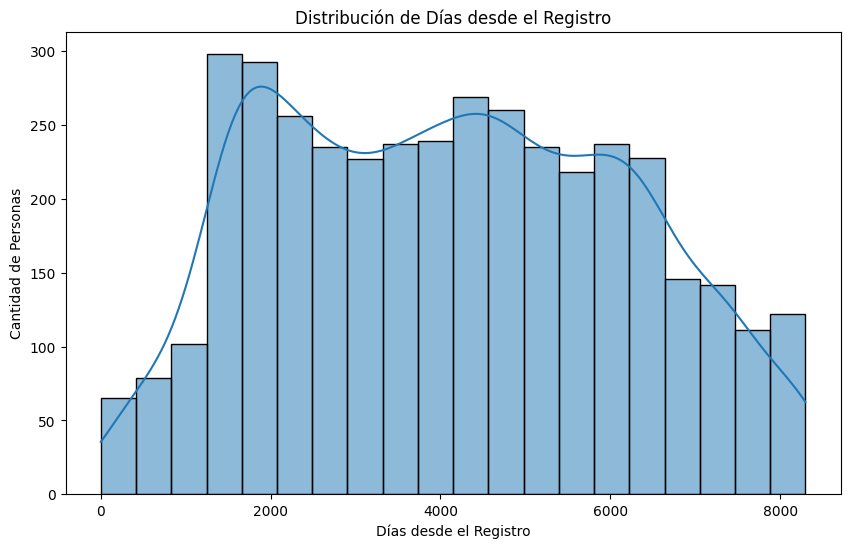

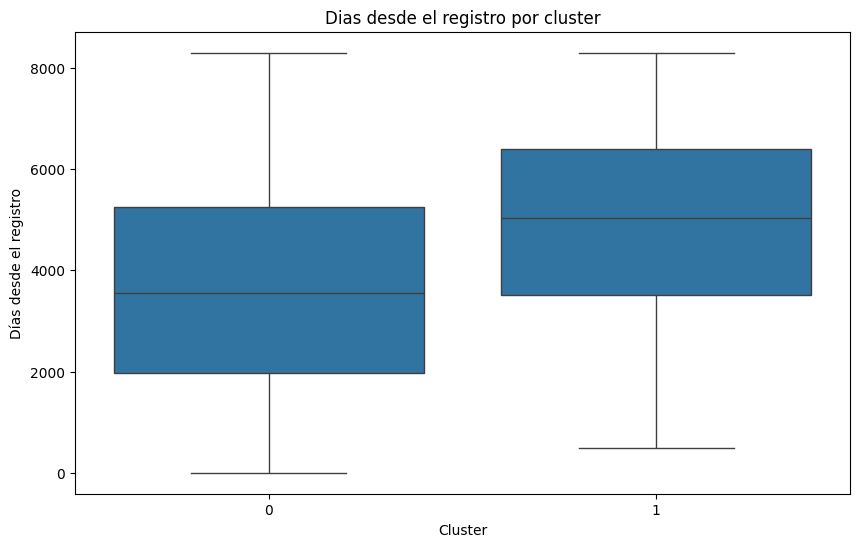

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(datos['Days_since_enroll'], kde=True)
plt.title('Distribución de Días desde el Registro')
plt.xlabel('Días desde el Registro')
plt.ylabel('Cantidad de Personas')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='Days_since_enroll', data=datos)
plt.title('Dias desde el registro por cluster')
plt.xlabel('Cluster')
plt.ylabel('Días desde el registro')
plt.show()


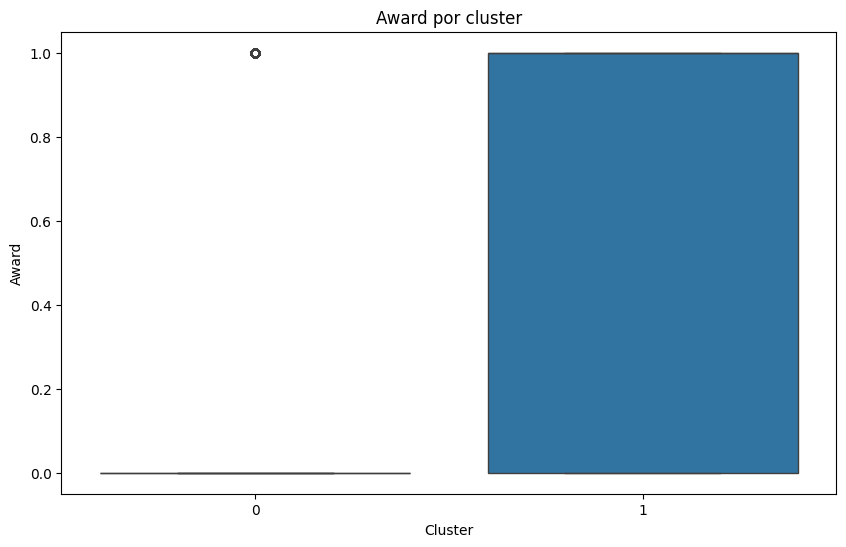

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='Award', data=datos)
plt.title('Award por cluster')
plt.xlabel('Cluster')
plt.ylabel('Award')
plt.show()


Millas recibidas tarjeta de crédito viajero frecuente:

En el cluster 0 se identifica que más de 2000 personas recibieron menos de 5000 millas, a comparación de las menos de 500 personas que recibieron entre 5000 y 10000 o 10001 y 25000.

En el cluster 1 los números están más distribuidos en los tres niveles superiores, con alrededor de 500 personas que recibieron entre 25001 y 50000 millas, entre 300 y 400 personas que recibieron entre 10001 y 25000 millas, y alrededor de 300 personas que recibieron más de 50000 millas.

Millas recibidas recompensa tarjeta de crédito:

Tanto en el cluster 0 como en el cluster 1, la gran mayoría de las personas recibieron menos de 5000 millas, lo que podría indicar que existe una oportunidad para ofrecer ofertas a los que más millas reciben para incentivar a los demás a consumir más.

Millas recibidas tarjeta de crédito negocio pequeño:

Tanto en el cluster 0 como en el 1 los números se distribuyen de manera similar, alrededor de 500 personas recibieron entre 25001 y 50000 millas por su uso de este tipo de tarjeta, entre 300 y 400 personas recibieron entre 10001 y 25000 millas y alrededor de 300 personas recibieron más de 50000 millas.

Número de transacciones en actividades diferentes al vuelo:

En el cluster 0, la gran mayoría se encuentra en el lado izquierdo, con 0, 1, 3 o 4 transacciones, en el lado derecho con más de 23 transacciones la cifra más alta es 9 personas que realizaron 24 transacciones.

En el cluster 1 se realizaron una cantidad mayor de transacciones, el pico se encuentra entre las 14 y las 19 transacciones, con 135 personas realizando 15 transacciones.

Millas de vuelo en los últimos 12 meses:

En el cluster 0 la mayor cantidad de millas registradas ronda las 6000-7000 millas, con una cantidad minima de registros, por otro lado, la menor cantidad de millas registradas se encuentra entre las 0 y las 1000 millas, con una cantidad máxima de registros de más de 2000 personas.

En el cluster 1 hay registros de hasta 30000 millas, registros grandes pero poco frecuentes, los registros menores son los más frecuentes, más de 1000 personas registraron entre 0 y 2000 millas, y a medida que la cantidad de millas aumentan, la frecuencia de los registros disminuye.

Cantidad de días desde el registro:

La cantidad de días inscritos se distribuye desde los 0 días hasta los 8000 días, la menor cantidad de personas están recién inscritos, en la primera gráfica se ven 3 picos, el primero está rondando los 2000 días, el segundo los 4000 y el tercero los 6000. La mayoría de las personas están entre los 2000 y los 6000 días de antigüedad, con registros bastante estables, a partir de los 6000 días las cantidades disminuyen hasta llegar a los 8000 días, alrededor de 100 personas llevan menos de 1000 días y alrededor de 150 personas llevan más de 6000 días.

Entre el cluster 0 y el 1, el cluster 0 tiene miembros más recientes mientras el cluster 1 tiene miembros más antiguos, lo que podría explicar la disparidad en los resultados.

Viajes gratis:

En el cluster 0, nadie a excepción de un caso particular ha recibido viajes gratis.

En el cluster 1, todos han recibido viajes gratis.
